---
title: "🖼️ Prediction using Neural Network"
author: "Maksim Ohvrill"
date: "5/1/2025"
format:
  html:
    toc: true
    toc-location: right
    code-fold: true
bibliography: references.bib
csl: ieee-with-url.csl
jupyter: Python
---

> Checking that the first part of the pipeline—where an image is input—produces the expected heatmap, and verifying that the logits and auxiliary data remain correctly aligned with the image.

Prediction Result

Label   Logit  Confidence  Prediction  Ground Truth
   Effusion -0.6700      0.3385           0             0
Atelectasis  0.3007      0.5746           1             1

CSV Data Row

IMGPATH              /home/maxvill/InfernoCalibNet/data/raw/xrays/x...
DISEASELABEL                           ['Atelectasis', 'Infiltration']
MULTIHOT                                                        [0, 1]
FOLLOWUP                                                             2
PATID                                                            19906
AGE                                                                 67
GENDER                                                               M
VP                                                                  AP
LOGIT_EFFUSION                                               -0.671172
LABEL_EFFUSION                                                       0
LOGIT_ATELECTASIS                                             0.300205
LABEL_ATELECTASIS                                                    1
Name: 10, dtype: object

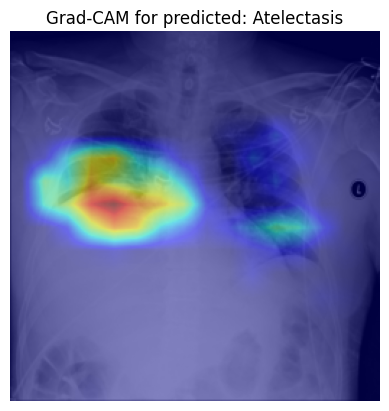

In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rich import print
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from CNN import InfernoCalibNet, ChestXRayDataset, CALIB_DIR

def runGradCAM(model: torch.nn.Module, input_tensor: torch.Tensor, device: torch.device, predicted_labels: list):
    model.eval()
    target_layer = model.base_model[-1]

    cam = GradCAM(model=model, target_layers=[target_layer])
    input_tensor = input_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    with torch.no_grad():
        output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(predicted_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    grayscale_cam = np.maximum(grayscale_cam, 0)
    grayscale_cam = grayscale_cam - grayscale_cam.min()
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    img = input_tensor.detach().cpu().squeeze().numpy()
    fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray")
    ax.imshow(grayscale_cam, cmap="jet", alpha=0.5)

    title = "Grad-CAM for predicted: " + ", ".join(predicted_labels)
    ax.set_title(title)
    plt.axis("off")
    plt.show()

def predict_single_entry(index: int = 1000):
    torch.cuda.empty_cache()

    df = pd.read_csv(CALIB_DIR / "calibration_test.csv")
    row = df.iloc[index]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2, model_type="resnet50").to(device)
    model.load_state_dict(torch.load(CALIB_DIR / "InfernoCalibNetML50.pth", weights_only=True))
    model.eval()

    ds = ChestXRayDataset(CALIB_DIR / "calibration_test.csv", transform=False)
    image_tensor, target_tensor = ds[index]
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))
        logits = output.cpu().squeeze()
        probs = torch.sigmoid(logits)
        predictions = (probs > 0.5).int()

    print("[bold green]Prediction Result")
    labels = ["Effusion", "Atelectasis"]
    predicted_labels = []

    rows = []
    for label, logit, prob, pred_val, true_val in zip(labels, logits.numpy(), probs.numpy(), predictions.numpy(), target_tensor.numpy()):
        if pred_val == 1:
            predicted_labels.append(label)
        rows.append({
            "Label": label,
            "Logit": round(float(logit), 4),
            "Confidence": round(float(prob), 4),
            "Prediction": int(pred_val),
            "Ground Truth": int(true_val)
        })

    df_preds = pd.DataFrame(rows)
    print(df_preds.to_string(index=False))

    print("[bold cyan]CSV Data Row")
    print(f"{row}")

    runGradCAM(model, image_tensor, device, predicted_labels)

predict_single_entry(index=10)
